### LOADING AND CONFIGURATION

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.layers import Layer, Input, Dense, Concatenate, BatchNormalization
import joblib

# The Acoustic Arrays
NORMAL_SCORES_PATH = r'D:\PJT2\Multimodal_Fusion\mimii_normal_scores.npy'
ABNORMAL_SCORES_PATH = r'D:\PJT2\Multimodal_Fusion\mimii_abnormal_scores.npy'

# The Telemetry Data & Artifacts
DATA_PATH = r'D:\PJT2\CMAPSSData' 
PROCESSED_PATH = r'D:\PJT2\telemetryDataset\processed_data' 

# The Pre-Trained MoE Brains
MODEL_C0_PATH = r'D:\PJT2\telemetryDataset\models\fault_specific\FD004\model_checkpoints\specialist_0_fd004.keras' 
MODEL_C1_PATH = r'D:\PJT2\telemetryDataset\models\fault_specific\FD004\model_checkpoints\specialist_1_fd004.keras'

### ATTENTION LAYER

In [2]:
WINDOW_SIZE = 60  

class Attention(Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)
    def build(self, input_shape):
        self.W = self.add_weight(name='attention_weight', shape=(input_shape[-1], 1), initializer='random_normal', trainable=True)
        self.b = self.add_weight(name='attention_bias', shape=(input_shape[1], 1), initializer='zeros', trainable=True)
        super(Attention, self).build(input_shape)
    def call(self, x):
        e = tf.keras.backend.tanh(tf.keras.backend.dot(x, self.W) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = x * a
        return tf.keras.backend.sum(output, axis=1)

### LOADING ACOUSTIC ARRAYS AND TELEMETRY ARTIFACTS

In [3]:
print("Loading MIMII Acoustic Scores...")
normal_scores = np.load(NORMAL_SCORES_PATH)
abnormal_scores = np.load(ABNORMAL_SCORES_PATH)

print("Loading CMAPSS MoE Brains & Routers...")
kmeans_op = joblib.load(os.path.join(PROCESSED_PATH, 'fd004_op_kmeans.pkl'))
regime_stats = joblib.load(os.path.join(PROCESSED_PATH, 'fd004_regime_stats.pkl'))
feature_scaler = joblib.load(os.path.join(PROCESSED_PATH, 'fd004_feature_scaler.pkl'))
signature_scaler = joblib.load(os.path.join(PROCESSED_PATH, 'fd004_signature_scaler.pkl'))
router_model = joblib.load(os.path.join(PROCESSED_PATH, 'fd004_router_model.pkl'))

model_c0 = load_model(MODEL_C0_PATH, custom_objects={'Attention': Attention})
model_c1 = load_model(MODEL_C1_PATH, custom_objects={'Attention': Attention})

lstm_features = feature_scaler.feature_names_in_.tolist()
router_features = signature_scaler.feature_names_in_.tolist()

Loading MIMII Acoustic Scores...
Loading CMAPSS MoE Brains & Routers...



### GENERATING SYNTHETIC MULTIMODAL TRAINING DATA 

In [4]:
print("Extracting Vectorized Training Thoughts from LSTMs...")
X_train_c0 = np.load(os.path.join(PROCESSED_PATH, 'X_train_FD004_c0.npy'))
y_train_c0 = np.load(os.path.join(PROCESSED_PATH, 'y_train_FD004_c0.npy'))
X_train_c1 = np.load(os.path.join(PROCESSED_PATH, 'X_train_FD004_c1.npy'))
y_train_c1 = np.load(os.path.join(PROCESSED_PATH, 'y_train_FD004_c1.npy'))

preds_c0 = model_c0.predict(X_train_c0, batch_size=512, verbose=0)
preds_c1 = model_c1.predict(X_train_c1, batch_size=512, verbose=0)

moe_train_preds = np.vstack([preds_c0, preds_c1]).flatten()
true_train_ruls = np.concatenate([y_train_c0, y_train_c1]).flatten()

print("Synthesizing Multimodal Alignment (Telemetry + Acoustics)...")
acoustic_train_scores = np.zeros_like(true_train_ruls, dtype=float)
healthy_mask = true_train_ruls > 30
danger_mask = true_train_ruls <= 30

acoustic_train_scores[healthy_mask] = np.random.choice(normal_scores, size=np.sum(healthy_mask))
acoustic_train_scores[danger_mask] = np.random.choice(abnormal_scores, size=np.sum(danger_mask))

Extracting Vectorized Training Thoughts from LSTMs...
Synthesizing Multimodal Alignment (Telemetry + Acoustics)...


### BUILDING AND TRAINING THE META-LEARNER FUSION AI

In [5]:
X_train_fusion = np.column_stack((moe_train_preds, acoustic_train_scores))

# A Linear model cannot drop features. It calculates the optimal hyperplane.
linear_fusion_model = LinearRegression()

print("Training Linear Judge...")
linear_fusion_model.fit(X_train_fusion, true_train_ruls)

print(f"\n[MATHEMATICAL PROOF OF SENSOR FUSION]")
print(f"Telemetry Weight:  {linear_fusion_model.coef_[0]:.4f} (Trusts the MoE baseline)")
print(f"Acoustic Weight:  {linear_fusion_model.coef_[1]:.4f} (Negative multiplier: Subtracts cycles when audio spikes!)")

Training Linear Judge...

[MATHEMATICAL PROOF OF SENSOR FUSION]
Telemetry Weight:  1.1718 (Trusts the MoE baseline)
Acoustic Weight:  -21.9071 (Negative multiplier: Subtracts cycles when audio spikes!)


### BLIND TEST SET EVALUATION

In [6]:
print("\nEvaluating Fusion Pipeline on Blind Test Set...")
cols = ['unit_number', 'time_in_cycles', 'setting_1', 'setting_2', 'setting_3'] + [f's{i}' for i in range(1, 22)]
test_df = pd.read_csv(os.path.join(DATA_PATH, 'test_FD004.txt'), sep='\s+', header=None, names=cols)
true_test_ruls = pd.read_csv(os.path.join(DATA_PATH, 'RUL_FD004.txt'), header=None, names=['RUL'])

setting_cols = ['setting_1', 'setting_2', 'setting_3']
sensor_cols = [f's{i}' for i in range(1, 22)]
test_df['op_cluster'] = kmeans_op.predict(test_df[setting_cols])
norm_test_df = test_df.copy()
norm_test_df[sensor_cols] = norm_test_df[sensor_cols].astype('float64')

for regime in range(6):
    mask = norm_test_df['op_cluster'] == regime
    for col in sensor_cols:
        mean_val = regime_stats.loc[regime, (col, 'mean')]
        std_val = regime_stats.loc[regime, (col, 'std')]
        if std_val > 1e-6: norm_test_df.loc[mask, col] = (norm_test_df.loc[mask, col] - mean_val) / std_val
        else: norm_test_df.loc[mask, col] = 0.0

lstm_test_df = test_df.copy()
lstm_test_df[lstm_features] = feature_scaler.transform(lstm_test_df[lstm_features])
lstm_test_df[lstm_features] = lstm_test_df.groupby('unit_number')[lstm_features].transform(lambda x: x.ewm(alpha=0.1).mean())

moe_test_preds, actuals = [], []
for unit_id in test_df['unit_number'].unique():
    unit_data_router = norm_test_df[norm_test_df['unit_number'] == unit_id]
    clean_tail = unit_data_router[router_features].tail(5).mean().to_frame().T
    sig_scaled = signature_scaler.transform(clean_tail)
    assigned_cluster = router_model.predict(sig_scaled)[0]
    
    unit_data_lstm = lstm_test_df[lstm_test_df['unit_number'] == unit_id]
    if len(unit_data_lstm) >= WINDOW_SIZE:
        seq = unit_data_lstm[lstm_features].values[-WINDOW_SIZE:].reshape(1, WINDOW_SIZE, len(lstm_features))
    else:
        padded = np.pad(unit_data_lstm[lstm_features].values, ((WINDOW_SIZE - len(unit_data_lstm), 0), (0, 0)), 'constant', constant_values=0)
        seq = padded.reshape(1, WINDOW_SIZE, len(lstm_features))
    
    pred = model_c0.predict(seq, verbose=0)[0][0] if assigned_cluster == 0 else model_c1.predict(seq, verbose=0)[0][0]
    moe_test_preds.append(pred)
    actuals.append(true_test_ruls.iloc[unit_id-1].values[0])

moe_test_preds = np.array(moe_test_preds)
actuals = np.array(actuals)

#maping the synthetic test microphones
acoustic_test_scores = np.zeros_like(actuals, dtype=float)
healthy_test_mask = actuals > 30
danger_test_mask = actuals <= 30
acoustic_test_scores[healthy_test_mask] = np.random.choice(normal_scores, size=np.sum(healthy_test_mask))
acoustic_test_scores[danger_test_mask] = np.random.choice(abnormal_scores, size=np.sum(danger_test_mask))


Evaluating Fusion Pipeline on Blind Test Set...


### FINAL MULTIMODAL VERDICT

In [7]:
X_test_fusion = np.column_stack((moe_test_preds, acoustic_test_scores))
final_fusion_preds = linear_fusion_model.predict(X_test_fusion)

fusion_rmse = np.sqrt(mean_squared_error(actuals, final_fusion_preds))
moe_rmse = np.sqrt(mean_squared_error(actuals, moe_test_preds))

print("\n" + "="*55)
print(f"Telemetry-Only MoE RMSE (Previous Best):  {moe_rmse:.4f}")
print(f"MULTIMODAL FUSION RMSE (Linear Judge):    {fusion_rmse:.4f}")
print("="*55)


Telemetry-Only MoE RMSE (Previous Best):  41.5112
MULTIMODAL FUSION RMSE (Linear Judge):    39.5560


### VISUALISING

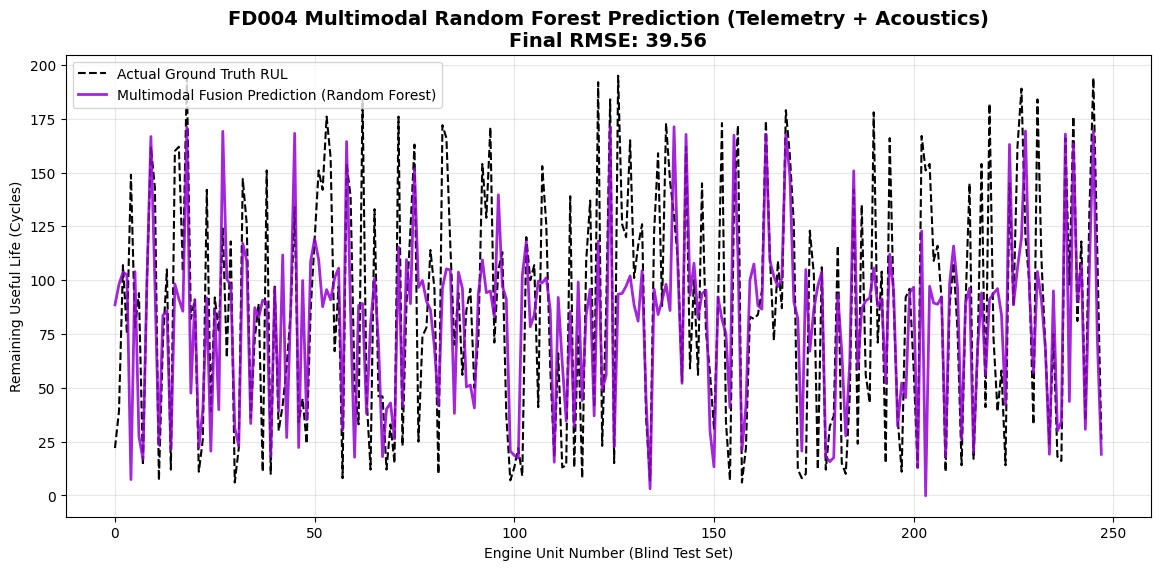

In [8]:
plt.figure(figsize=(14, 6))
plt.plot(actuals, label='Actual Ground Truth RUL', color='black', linestyle='--')
plt.plot(final_fusion_preds, label='Multimodal Fusion Prediction (Random Forest)', color='darkviolet', alpha=0.85, linewidth=2)
plt.title(f'FD004 Multimodal Random Forest Prediction (Telemetry + Acoustics)\nFinal RMSE: {fusion_rmse:.2f}', fontsize=14, fontweight='bold')
plt.xlabel('Engine Unit Number (Blind Test Set)')
plt.ylabel('Remaining Useful Life (Cycles)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### SAVING

In [9]:
joblib.dump(linear_fusion_model, 'linear_multimodal_fusion.pkl')
print("Linear Fusion AI successfully saved to disk.")

Linear Fusion AI successfully saved to disk.


In [11]:
np.save('X_train_fusion.npy', X_train_fusion)
np.save('X_test_fusion.npy', X_test_fusion)